DATA PREPROCESSING PIPELINE

 Loaded Titanic dataset from train.csv

Dataset Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  

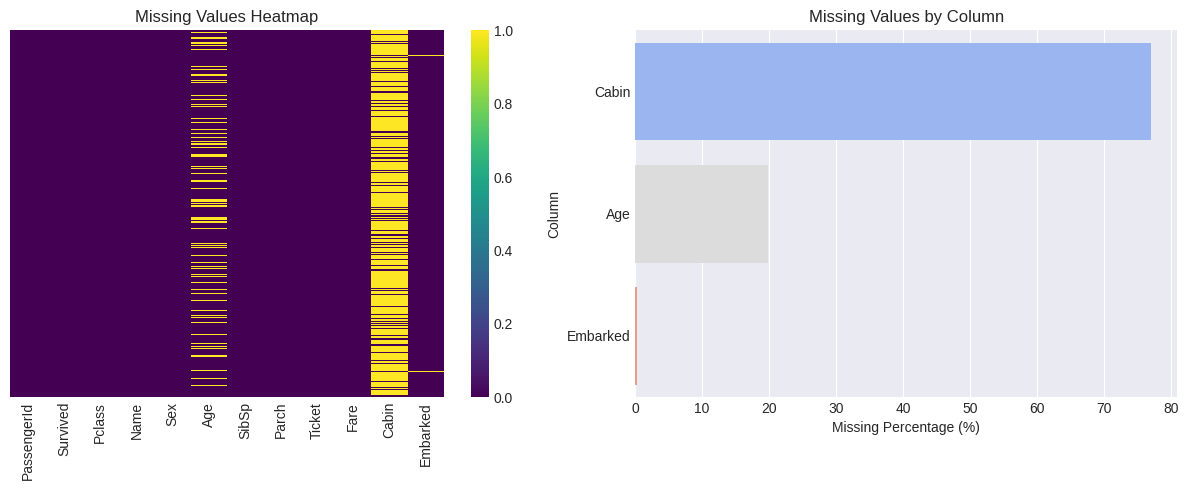


SECTION 2: HANDLING MISSING VALUES

 Handling missing values in 'Age':
 Filled with MEAN: 29.70

 Handling missing values in 'Cabin':
 Filled with MODE: B96 B98

 Handling missing values in 'Embarked':
 Filled with MODE: S

Missing Values After Handling:
0 missing values remaining
All missing values have been handled successfully!

SECTION 3: OUTLIER DETECTION AND ANALYSIS

Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


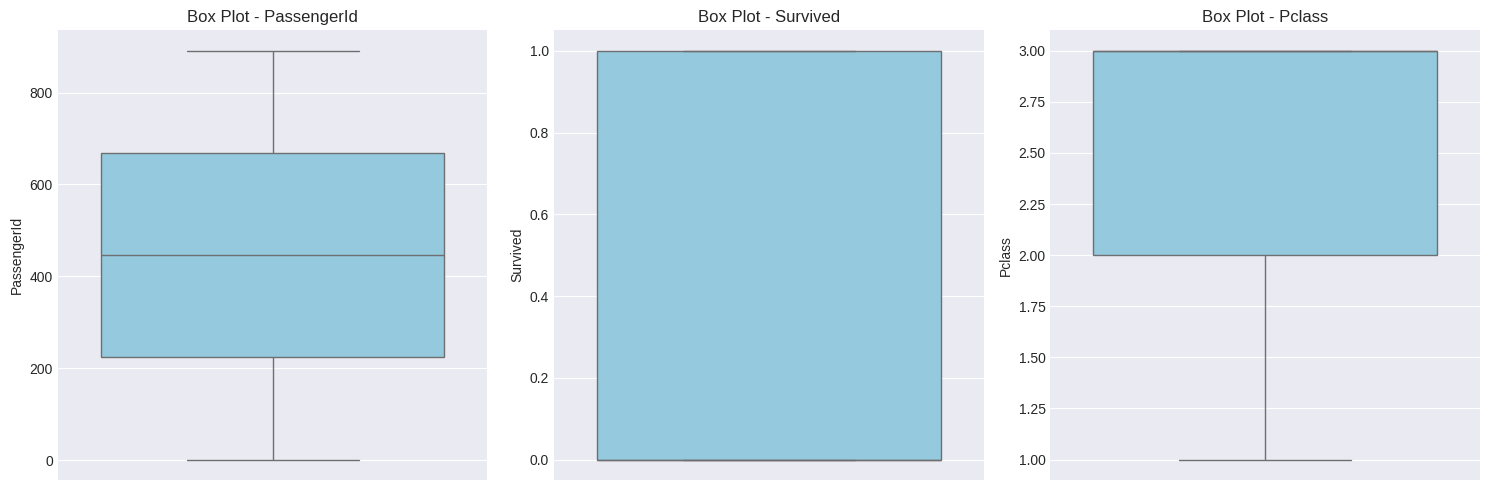


 Outlier Detection using IQR (Interquartile Range) Method:

   PassengerId:
      Q1 = 223.50, Q3 = 668.50, IQR = 445.00
      Normal Range: [-444.00, 1336.00]
      Outliers found: 0 (0.00%)

   Survived:
      Q1 = 0.00, Q3 = 1.00, IQR = 1.00
      Normal Range: [-1.50, 2.50]
      Outliers found: 0 (0.00%)

   Pclass:
      Q1 = 2.00, Q3 = 3.00, IQR = 1.00
      Normal Range: [0.50, 4.50]
      Outliers found: 0 (0.00%)

   Age:
      Q1 = 22.00, Q3 = 35.00, IQR = 13.00
      Normal Range: [2.50, 54.50]
      Outliers found: 66 (7.41%)

   SibSp:
      Q1 = 0.00, Q3 = 1.00, IQR = 1.00
      Normal Range: [-1.50, 2.50]
      Outliers found: 46 (5.16%)

   Parch:
      Q1 = 0.00, Q3 = 0.00, IQR = 0.00
      Normal Range: [0.00, 0.00]
      Outliers found: 213 (23.91%)

   Fare:
      Q1 = 7.91, Q3 = 31.00, IQR = 23.09
      Normal Range: [-26.72, 65.63]
      Outliers found: 116 (13.02%)

Outlier Summary Table:
        Column Lower Bound Upper Bound  Outlier Count Outlier %
0  Passen

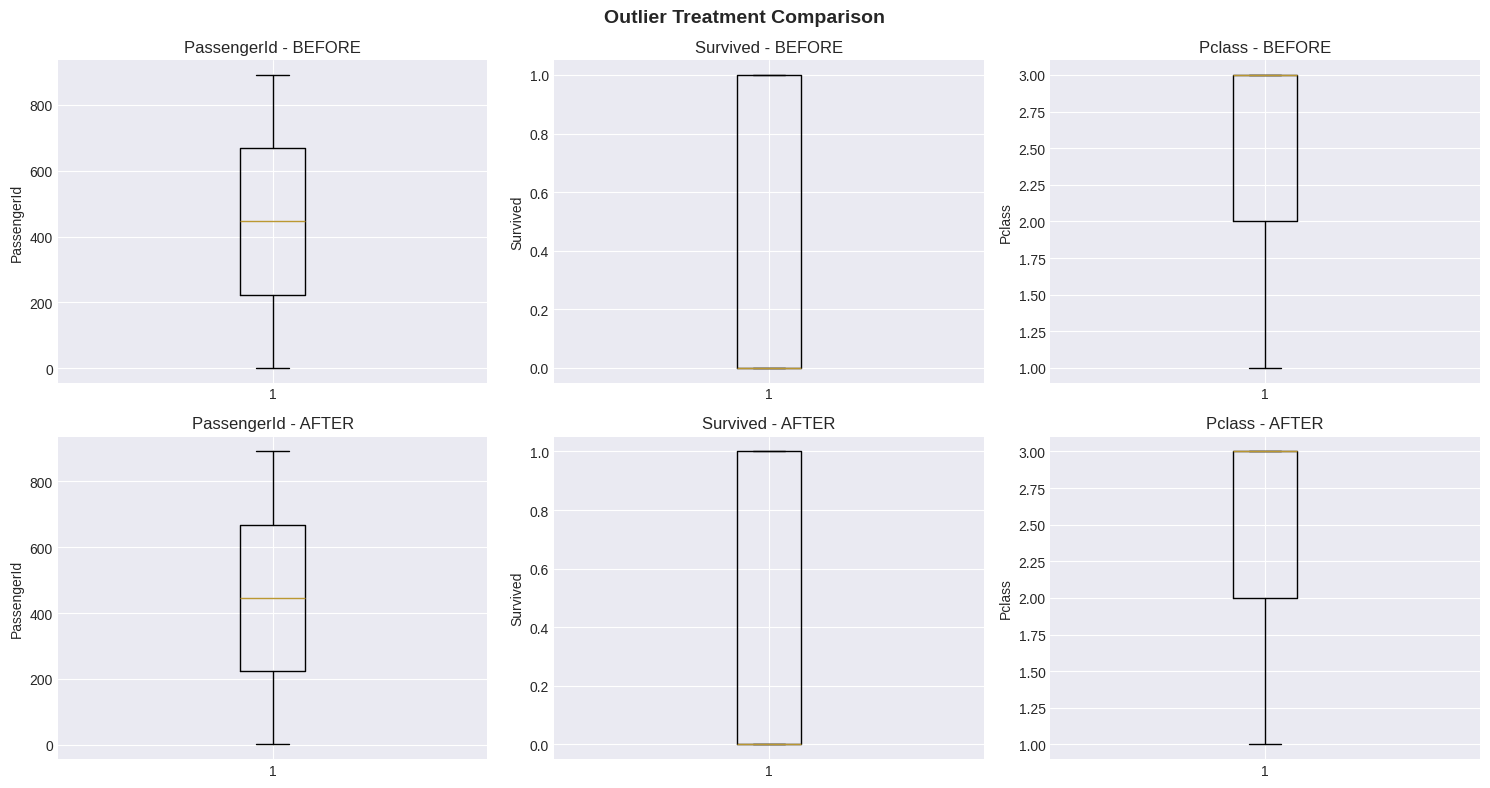


SECTION 5: FEATURE SCALING AND NORMALIZATION

Data shape before scaling: (891, 7)

Original Data Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  Parch  \
count   891.000000  891.000000  891.000000  891.000000  891.000000  891.0   
mean    446.000000    0.383838    2.308642   29.376817    0.426487    0.0   
std     257.353842    0.486592    0.836071   12.062035    0.708246    0.0   
min       1.000000    0.000000    1.000000    2.500000    0.000000    0.0   
25%     223.500000    0.000000    2.000000   22.000000    0.000000    0.0   
50%     446.000000    0.000000    3.000000   29.699118    0.000000    0.0   
75%     668.500000    1.000000    3.000000   35.000000    1.000000    0.0   
max     891.000000    1.000000    3.000000   54.500000    2.500000    0.0   

             Fare  
count  891.000000  
mean    24.046813  
std     20.481625  
min      0.000000  
25%      7.910400  
50%     14.454200  
75%     31.000000  
max     65.634400  

---------------

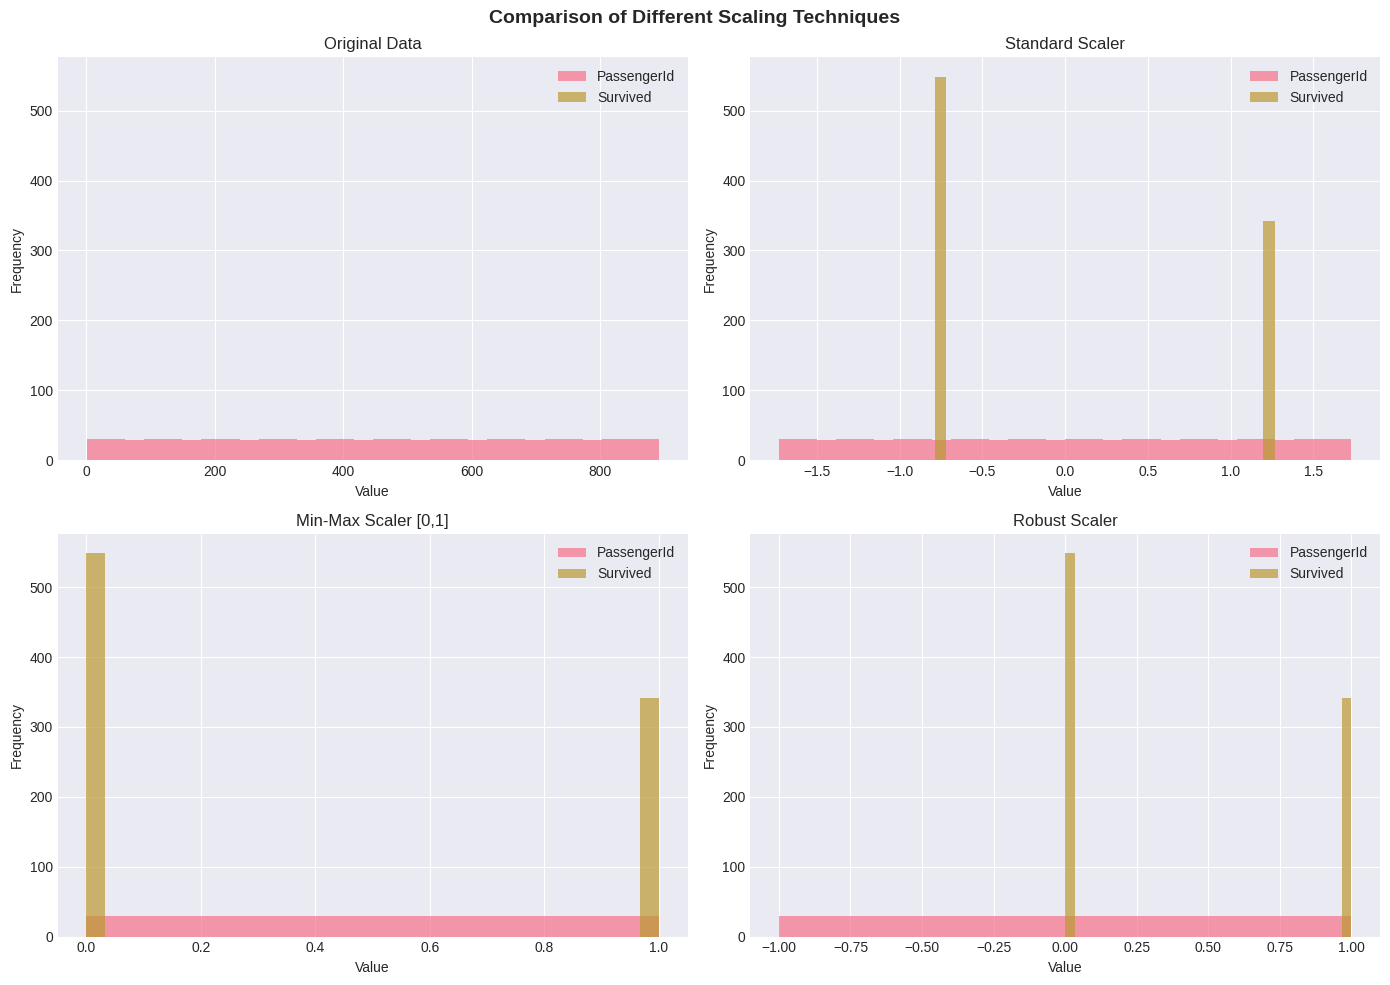


SECTION 6: TRAIN-TEST SPLIT

 Target variable: Survived

 Train-Test Split Results:
   Total samples: 891
   Training set size: 712 (79.9%)
   Testing set size: 179 (20.1%)
   Features: 7

 Training Set Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  Parch  \
count   712.000000  712.000000  712.000000  712.000000  712.000000  712.0   
mean     -0.006198   -0.000846    0.000415    0.008445   -0.030078    0.0   
std       1.000996    1.000500    0.997560    1.003520    0.973119    0.0   
min      -1.730108   -0.789272   -1.566107   -2.229467   -0.602512    0.0   
25%      -0.867970   -0.789272   -0.369365   -0.611917   -0.602512    0.0   
50%      -0.025271   -0.789272    0.827377    0.026735   -0.602512    0.0   
75%       0.860194    1.266990    0.827377    0.549402    0.810220    0.0   
max       1.730108    1.266990    0.827377    2.084001    2.929318    0.0   

             Fare  
count  712.000000  
mean    -0.004463  
std      1.001812  
min     -1

In [3]:
# ===========================================
# DATA PREPROCESSING TASK - TASK 2
# Handle Missing Values, Outliers, Feature Scaling
# Rhombix Technologies Data Science Internship
# ===========================================

# ---------- 1. IMPORT LIBRARIES ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("DATA PREPROCESSING PIPELINE")
print("="*60)

# ---------- 2. LOAD DATASET ----------

# Option 1: Titanic dataset
try:
    df = pd.read_csv('train.csv')
    print("\n Loaded Titanic dataset from train.csv")
except:
    # Option 2: Sample dataset create karein agar Titanic nahi hai
    print("\n Titanic dataset not found. Creating sample dataset...")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'Age': np.random.normal(30, 10, n_samples),
        'Salary': np.random.normal(50000, 15000, n_samples),
        'Experience': np.random.normal(8, 5, n_samples),
        'Score': np.random.normal(75, 15, n_samples),
        'Income': np.random.exponential(50000, n_samples)
    })
    # Introduce missing values
    for col in ['Age', 'Salary', 'Experience']:
        missing_idx = np.random.choice(n_samples, size=50, replace=False)
        df.loc[missing_idx, col] = np.nan
    # Introduce outliers
    outlier_idx = np.random.choice(n_samples, size=20, replace=False)
    df.loc[outlier_idx, 'Salary'] = df.loc[outlier_idx, 'Salary'] * 5
    print("Created sample dataset with missing values and outliers")

print(f"\nDataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# ---------- 3. EXPLORE MISSING VALUES ----------

print("\n" + "="*60)
print("SECTION 1: MISSING VALUES ANALYSIS")
print("="*60)

# 3.1 Check missing values count
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing Percentage': missing_percentages.values
}).sort_values('Missing Percentage', ascending=False)

print("\n Missing Values Summary:")
print(missing_df)

# 3.2 Visualize missing values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')

plt.subplot(1, 2, 2)
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) > 0:
    sns.barplot(x='Missing Percentage', y='Column', data=missing_df, palette='coolwarm')
    plt.title('Missing Values by Column')
    plt.xlabel('Missing Percentage (%)')
else:
    plt.text(0.5, 0.5, 'No Missing Values Found!', ha='center', va='center', fontsize=14)
    plt.title('Missing Values')

plt.tight_layout()
plt.show()

# ---------- 4. HANDLE MISSING VALUES ----------

print("\n" + "="*60)
print("SECTION 2: HANDLING MISSING VALUES")
print("="*60)

# Create a copy of original data for comparison
df_cleaned = df.copy()

# 4.1 Different strategies for different columns

for column in df_cleaned.columns:
    if df_cleaned[column].isnull().sum() > 0:

        print(f"\n Handling missing values in '{column}':")

        # Check if column is numerical
        if df_cleaned[column].dtype in ['int64', 'float64']:

            # Strategy 1: Mean Imputation (for normally distributed data)
            mean_value = df_cleaned[column].mean()
            df_cleaned[column].fillna(mean_value, inplace=True)
            print(f" Filled with MEAN: {mean_value:.2f}")

            # Alternative strategies (commented - aap try kar sakte ho)
            # Median Imputation (for skewed data)
            # median_value = df_cleaned[column].median()
            # df_cleaned[column].fillna(median_value, inplace=True)

            # Forward Fill (for time series)
            # df_cleaned[column].fillna(method='ffill', inplace=True)

        else:
            # Categorical column - fill with mode (most frequent)
            mode_value = df_cleaned[column].mode()[0]
            df_cleaned[column].fillna(mode_value, inplace=True)
            print(f" Filled with MODE: {mode_value}")

# Verify missing values are handled
print("\n" + "="*50)
print("Missing Values After Handling:")
print(df_cleaned.isnull().sum().sum(), "missing values remaining")
if df_cleaned.isnull().sum().sum() == 0:
    print("All missing values have been handled successfully!")

# ---------- 5. OUTLIER DETECTION AND ANALYSIS ----------

print("\n" + "="*60)
print("SECTION 3: OUTLIER DETECTION AND ANALYSIS")
print("="*60)

# Select only numerical columns
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical columns: {numerical_cols}")

# 5.1 Visualize outliers using Box Plots
plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_cols[:3]):  # First 3 columns for visualization
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_cleaned[col], color='skyblue')
    plt.title(f'Box Plot - {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# 5.2 IQR Method to detect outliers
print("\n Outlier Detection using IQR (Interquartile Range) Method:")

outlier_summary = []

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df_cleaned)) * 100

    outlier_summary.append({
        'Column': col,
        'Lower Bound': f"{lower_bound:.2f}",
        'Upper Bound': f"{upper_bound:.2f}",
        'Outlier Count': outlier_count,
        'Outlier %': f"{outlier_percentage:.2f}%"
    })

    print(f"\n   {col}:")
    print(f"      Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"      Normal Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"      Outliers found: {outlier_count} ({outlier_percentage:.2f}%)")

outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "="*50)
print("Outlier Summary Table:")
print(outlier_df)

# ---------- 6. HANDLE OUTLIERS ----------

print("\n" + "="*60)
print("SECTION 4: HANDLING OUTLIERS")
print("="*60)

df_no_outliers = df_cleaned.copy()

# 6.1 Different methods to handle outliers

for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    original_outlier_count = len(df_no_outliers[(df_no_outliers[col] < lower_bound) |
                                                  (df_no_outliers[col] > upper_bound)])

    if original_outlier_count > 0:
        print(f"\n Handling outliers in '{col}':")
        print(f"   Original outliers: {original_outlier_count}")

        # Method 1: Capping (Winsorization) - Recommended
        df_no_outliers[col] = df_no_outliers[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"  Method used: CAPPING (values clipped to [{lower_bound:.2f}, {upper_bound:.2f}])")


# Verify outliers after handling
print("\n" + "="*50)
print(" Outliers After Handling:")

for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    remaining_outliers = len(df_no_outliers[(df_no_outliers[col] < lower_bound) |
                                              (df_no_outliers[col] > upper_bound)])
    print(f"   {col}: {remaining_outliers} outliers remaining")

# 6.2 Visualize before and after outlier handling
fig, axes = plt.subplots(2, len(numerical_cols[:3]), figsize=(15, 8))

for i, col in enumerate(numerical_cols[:3]):
    # Before
    axes[0, i].boxplot(df_cleaned[col].dropna())
    axes[0, i].set_title(f'{col} - BEFORE')
    axes[0, i].set_ylabel(col)

    # After
    axes[1, i].boxplot(df_no_outliers[col])
    axes[1, i].set_title(f'{col} - AFTER')
    axes[1, i].set_ylabel(col)

plt.suptitle('Outlier Treatment Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- 7. FEATURE SCALING / NORMALIZATION ----------

print("\n" + "="*60)
print("SECTION 5: FEATURE SCALING AND NORMALIZATION")
print("="*60)

# Prepare data for scaling (use the data after outlier treatment)
X = df_no_outliers[numerical_cols].copy()

print(f"\nData shape before scaling: {X.shape}")
print("\nOriginal Data Statistics:")
print(X.describe())

# 7.1 Different Scaling Techniques

# Method 1: StandardScaler (Z-score normalization)
# Formula: (x - mean) / standard deviation
print("\n" + "-"*50)
print("METHOD 1: STANDARD SCALER (Z-Score Normalization)")
print("-"*50)
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)
X_standard_df = pd.DataFrame(X_standard, columns=numerical_cols)
print("Formula: (x - mean) / std")
print(f"After scaling - Mean: {X_standard_df.mean().mean():.2f}, Std: {X_standard_df.std().mean():.2f}")
print(X_standard_df.describe())

# Method 2: MinMaxScaler (Normalization to [0,1] range)
# Formula: (x - min) / (max - min)
print("\n" + "-"*50)
print("METHOD 2: MIN-MAX SCALER (Range [0,1])")
print("-"*50)
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=numerical_cols)
print("Formula: (x - min) / (max - min)")
print(f"After scaling - Min: {X_minmax_df.min().min():.2f}, Max: {X_minmax_df.max().max():.2f}")
print(X_minmax_df.describe())

# Method 3: RobustScaler (Robust to outliers)
# Formula: (x - median) / IQR
print("\n" + "-"*50)
print("METHOD 3: ROBUST SCALER (Median & IQR based)")
print("-"*50)
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)
X_robust_df = pd.DataFrame(X_robust, columns=numerical_cols)
print("Formula: (x - median) / IQR")
print(f"After scaling - Median: {X_robust_df.median().mean():.2f}")
print(X_robust_df.describe())

# 7.2 Visualize the effect of scaling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data
axes[0, 0].hist(X[numerical_cols[0]], bins=30, alpha=0.7, label=numerical_cols[0])
axes[0, 0].hist(X[numerical_cols[1]] if len(numerical_cols) > 1 else X[numerical_cols[0]],
                bins=30, alpha=0.7, label=numerical_cols[1] if len(numerical_cols) > 1 else numerical_cols[0])
axes[0, 0].set_title('Original Data')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

# Standard Scaler
axes[0, 1].hist(X_standard_df[numerical_cols[0]], bins=30, alpha=0.7, label=numerical_cols[0])
axes[0, 1].hist(X_standard_df[numerical_cols[1]] if len(numerical_cols) > 1 else X_standard_df[numerical_cols[0]],
                bins=30, alpha=0.7, label=numerical_cols[1] if len(numerical_cols) > 1 else numerical_cols[0])
axes[0, 1].set_title('Standard Scaler')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')

# MinMax Scaler
axes[1, 0].hist(X_minmax_df[numerical_cols[0]], bins=30, alpha=0.7, label=numerical_cols[0])
axes[1, 0].hist(X_minmax_df[numerical_cols[1]] if len(numerical_cols) > 1 else X_minmax_df[numerical_cols[0]],
                bins=30, alpha=0.7, label=numerical_cols[1] if len(numerical_cols) > 1 else numerical_cols[0])
axes[1, 0].set_title('Min-Max Scaler [0,1]')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')

# Robust Scaler
axes[1, 1].hist(X_robust_df[numerical_cols[0]], bins=30, alpha=0.7, label=numerical_cols[0])
axes[1, 1].hist(X_robust_df[numerical_cols[1]] if len(numerical_cols) > 1 else X_robust_df[numerical_cols[0]],
                bins=30, alpha=0.7, label=numerical_cols[1] if len(numerical_cols) > 1 else numerical_cols[0])
axes[1, 1].set_title('Robust Scaler')
axes[1, 1].legend()
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')

plt.suptitle('Comparison of Different Scaling Techniques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- 8. TRAIN-TEST SPLIT ----------

print("\n" + "="*60)
print("SECTION 6: TRAIN-TEST SPLIT")
print("="*60)

# Choose which scaled data to use (let's use StandardScaler as it's most common)
X_final = X_standard_df
y_final = df_no_outliers[numerical_cols[0]] if 'Survived' not in df_no_outliers.columns else df_no_outliers['Survived']

# If Titanic dataset hai toh target variable 'Survived' use karein
if 'Survived' in df_no_outliers.columns:
    y_final = df_no_outliers['Survived']
    print("\n Target variable: Survived")
else:
    print(f"\n Using '{numerical_cols[0]}' as target variable (example)")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y_final if len(y_final.unique()) <= 10 else None  # Stratify for classification
)

print("\n Train-Test Split Results:")
print(f"   Total samples: {len(X_final)}")
print(f"   Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X_final)*100:.1f}%)")
print(f"   Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X_final)*100:.1f}%)")
print(f"   Features: {X_train.shape[1]}")

print("\n Training Set Statistics:")
print(X_train.describe())

print("\n Testing Set Statistics:")
print(X_test.describe())

# ---------- 9. VERIFICATION AND VALIDATION ----------

print("\n" + "="*60)
print("SECTION 7: VERIFICATION AND VALIDATION")
print("="*60)

# 9.1 Check if missing values are completely handled
assert df_cleaned.isnull().sum().sum() == 0, "Still have missing values!"
print(" No missing values remaining")

# 9.2 Check scaling properties
print("\n Scaling Verification:")
print(f"   Training data mean: {X_train.mean().mean():.6f}")
print(f"   Training data std: {X_train.std().mean():.6f}")
print(f"   Features are centered around 0 with unit variance")

# 9.3 Check train-test distribution similarity
print("\n Train-Test Distribution Check:")
for col in X_train.columns[:2]:  # Check first 2 columns
    train_mean = X_train[col].mean()
    test_mean = X_test[col].mean()
    print(f"   {col}: Train mean={train_mean:.4f}, Test mean={test_mean:.4f}, Difference={abs(train_mean-test_mean):.4f}")

# ---------- 10. SAVE PREPROCESSED DATA ----------

print("\n" + "="*60)
print("SECTION 8: SAVE PREPROCESSED DATA")
print("="*60)

# Save the processed data for future use
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print(" Saved files:")
print("   - X_train.csv (Training features)")
print("   - X_test.csv (Testing features)")
print("   - y_train.csv (Training labels)")
print("   - y_test.csv (Testing labels)")

# Save the scalers for future use
import joblib
joblib.dump(scaler_standard, 'standard_scaler.pkl')
print("   - standard_scaler.pkl (Scaler object for future use)")


print("\n TASK 2 COMPLETED SUCCESSFULLY!")
print("="*60)